In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [12]:
TEST_TYPES = ["sum", "weighted", "log"]
SHAREY = False  # set True to synchronize y-axes across subplots

In [13]:
group_objectives_df = pd.read_csv("data/singlethread_group_time.csv").set_index(["test_type", "num_cpus", "n"]).rename({"_get_grouped_objectives": "group_time"}, axis=1)
group_objectives_df.head()

,,,num_iterations,__init__,group_time,result
test_type,num_cpus,n,,,,
sum,1,50,0,0.0938,0.0304,0
weighted,1,50,0,0.1106,0.0324,0
log,1,50,0,0.1307,0.0268,0
sum,1,100,0,0.2543,0.1506,0
weighted,1,100,0,0.2511,0.1563,0


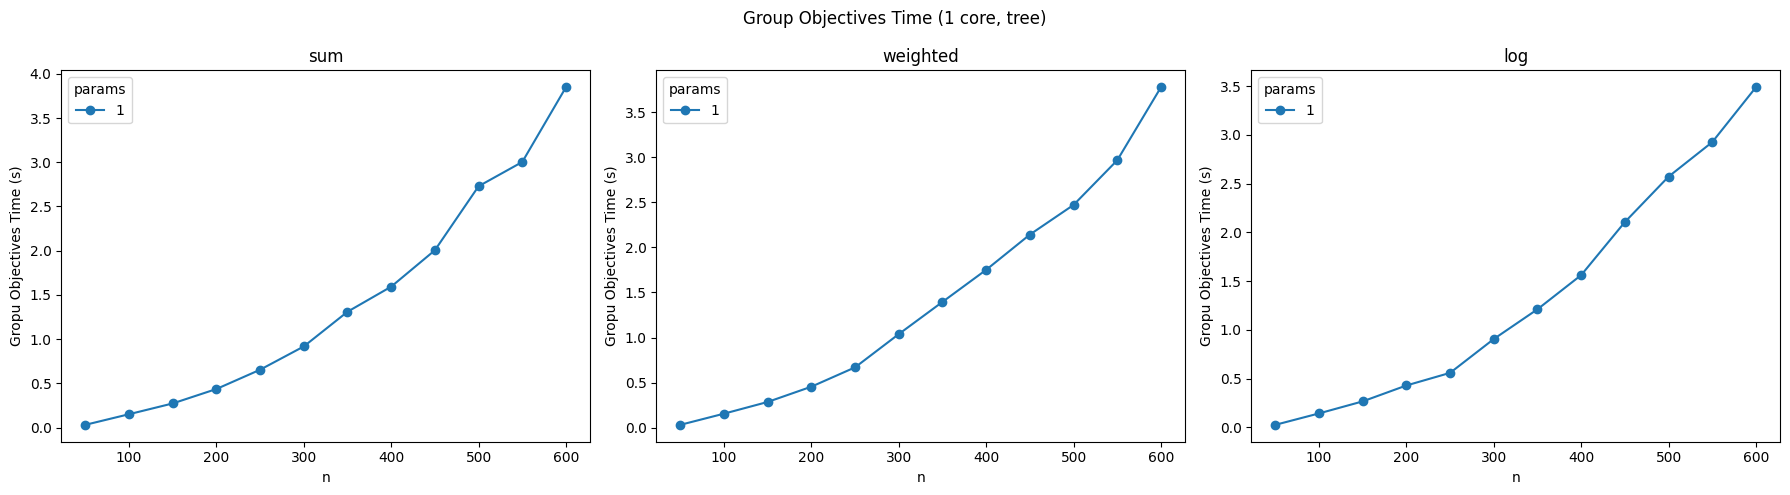

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = group_objectives_df.loc[test_type].unstack(["num_cpus"])
    df_t["group_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["group_time"].columns, title="params")
    ax.set_xlabel("n")
    ax.set_ylabel("Gropu Objectives Time (s)")
    ax.set_title(test_type)
fig.suptitle("Group Objectives Time (1 core, tree)")
fig.tight_layout()
plt.show()

In [5]:
df = pd.read_csv("data/benchmark_new.csv").set_index(["test_type", "n", "num_cpus"])
df = df.rename({"solve": "total_time", "dede_solve_time": "admm_time"}, axis=1)
df["admm_time_per_iter"] = df["admm_time"] / df["dede_iterations"]
df["group_time"] = df["_get_grouped_objectives"]
df["nonsolve_time"] = df["total_time"] - df["admm_time"]
df["misc_time"] = df["total_time"] - (df["get_subproblems"] + df["populate_vars_with_solution"] + df["_get_grouped_objectives"] + df["admm_time"])
df.head()

,,,num_iterations,admm_time,dede_iterations,__init__,_get_grouped_objectives,get_relative_residuals_and_epsilon,get_subproblems,populate_vars_with_solution,total_time,result,admm_time_per_iter,group_time,nonsolve_time,misc_time
test_type,n,num_cpus,,,,,,,,,,,,,,
sum,500,64,0,50.157770,20,4.9520,2.5800,1.6148,12.0921,2.4548,80.5844,124749.972030,2.507889,2.5800,30.426630,13.299730
weighted,500,64,0,75.112099,30,4.7488,2.8276,1.6718,12.4911,2.5203,105.5261,2787.706335,2.503737,2.8276,30.414001,12.575001
log,500,64,0,52.356727,30,4.8274,2.8596,1.6636,12.7033,2.4394,83.3391,2612.825024,1.745224,2.8596,30.982373,12.980073
sum,500,32,0,84.093318,20,4.7481,2.8963,1.7129,10.9151,2.3798,113.5616,124749.972030,4.204666,2.8963,29.468282,13.277082
weighted,500,32,0,125.682075,30,4.8974,2.9862,1.6286,10.7608,2.3833,155.2995,2880.550136,4.189402,2.9862,29.617425,13.487125


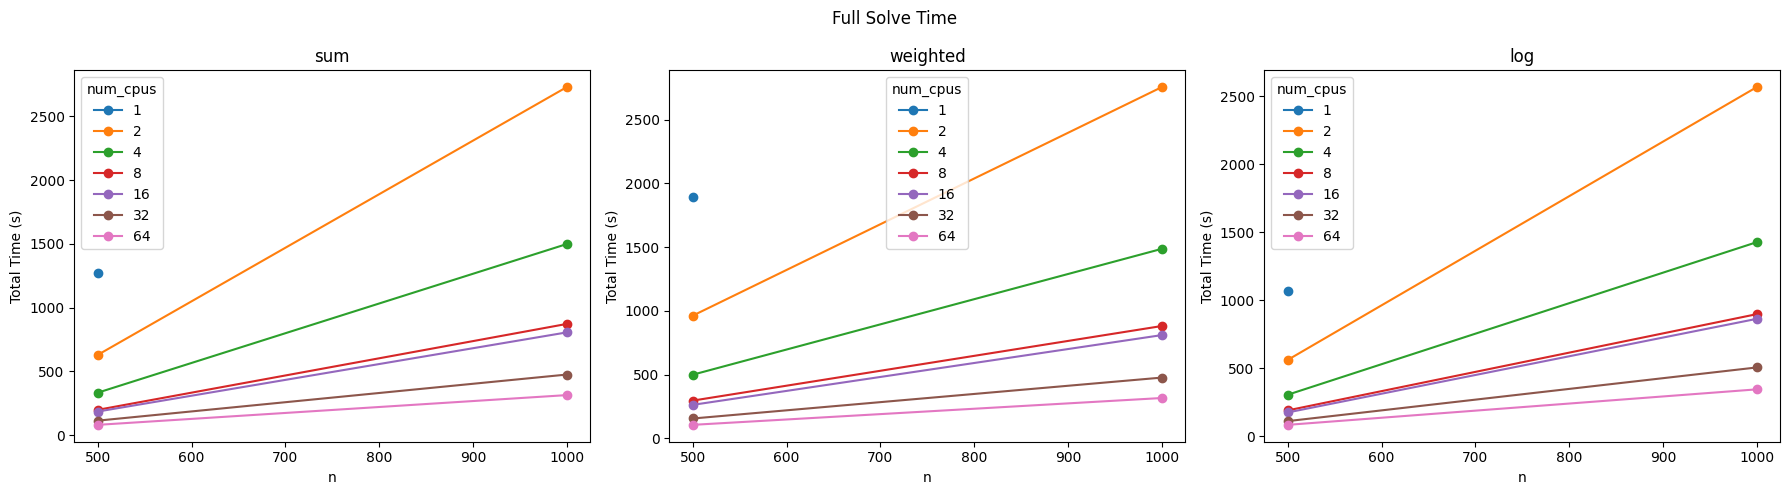

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["total_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["total_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Total Time (s)")
    ax.set_title(test_type)
fig.suptitle("Full Solve Time")
fig.tight_layout()
plt.show()

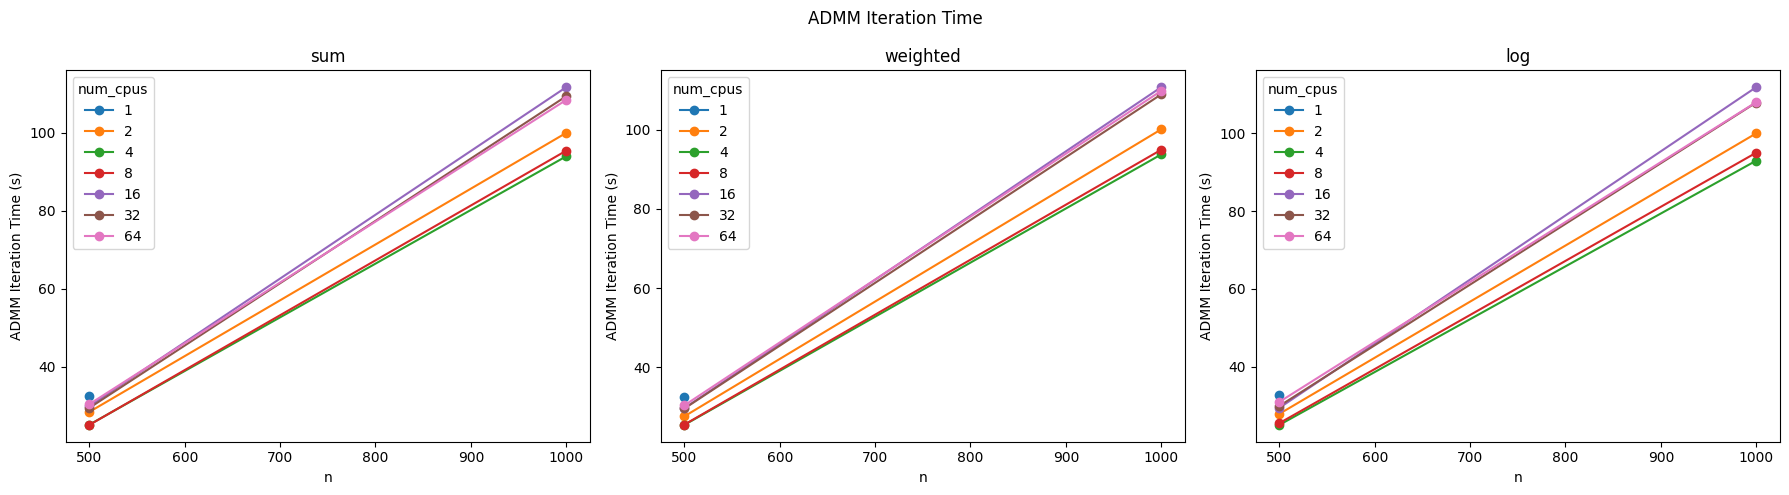

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["nonsolve_time"].plot(ax=ax, marker="o")
    ax.legend(  (df_t["nonsolve_time"]).columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time")
fig.tight_layout()
plt.show()

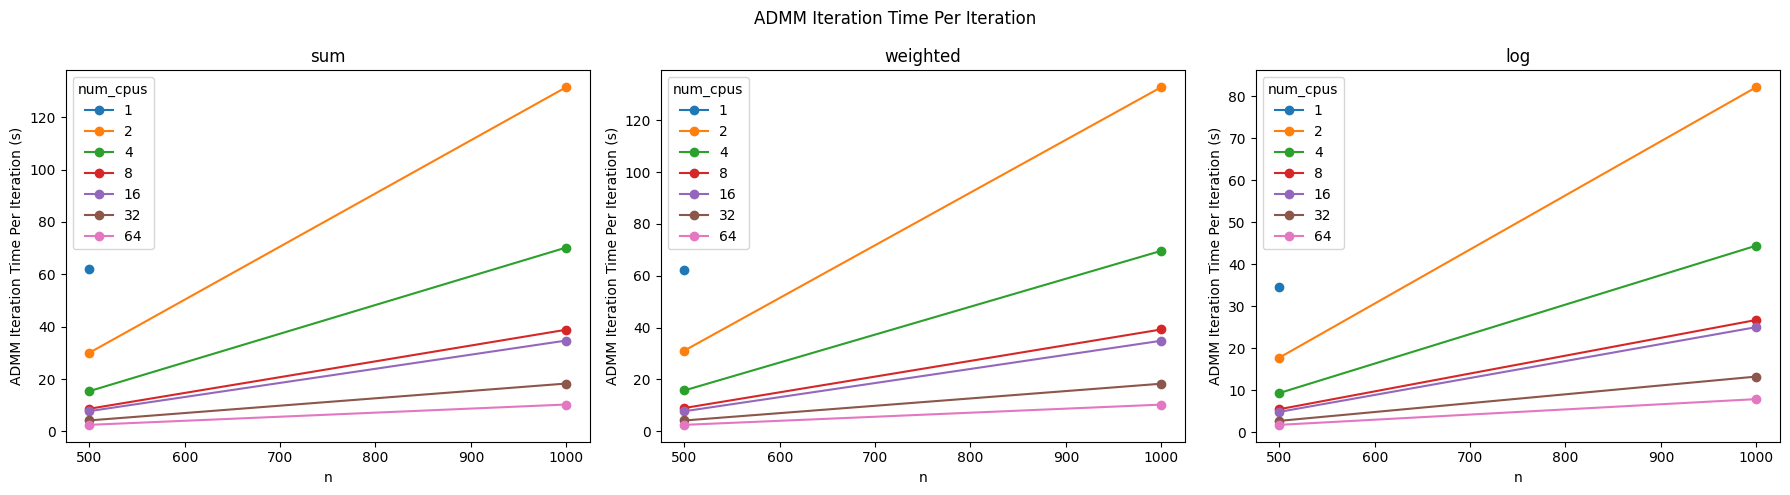

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["admm_time_per_iter"].plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time_per_iter"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("ADMM Iteration Time Per Iteration (s)")
    ax.set_title(test_type)
fig.suptitle("ADMM Iteration Time Per Iteration")
fig.tight_layout()
plt.show()

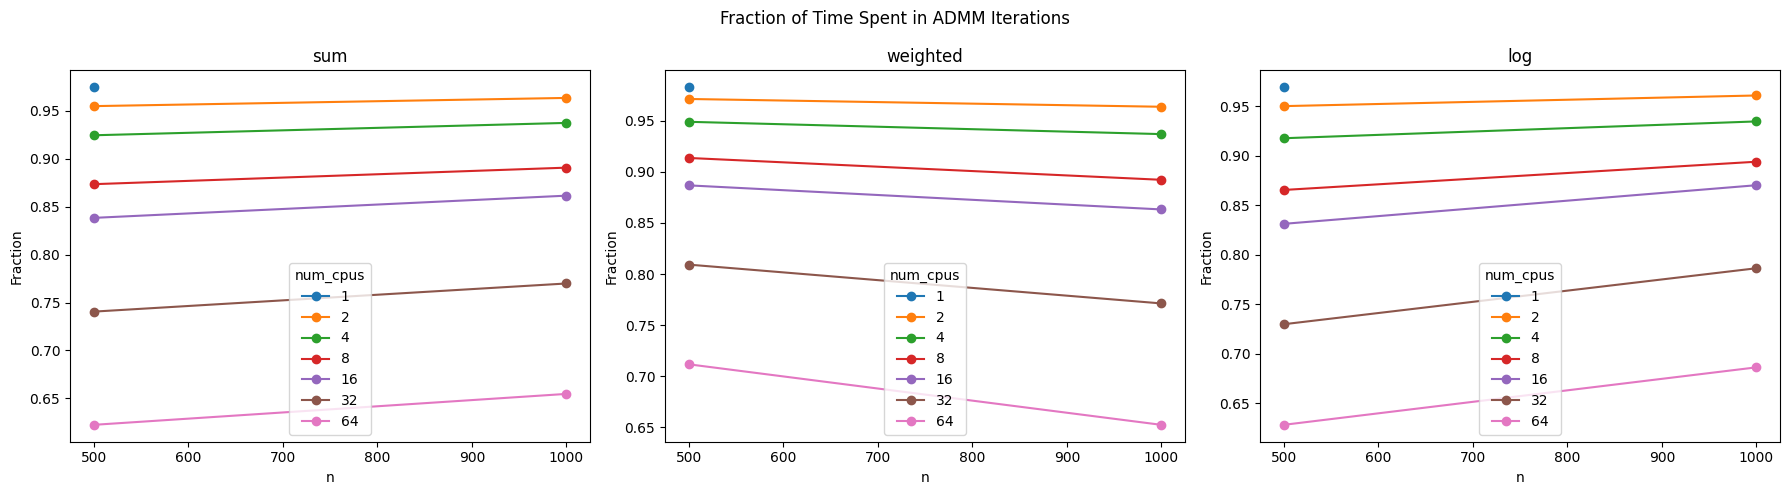

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    (df_t["admm_time"] / df_t["total_time"]).plot(ax=ax, marker="o")
    ax.legend(df_t["admm_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Fraction")
    ax.set_title(test_type)
fig.suptitle("Fraction of Time Spent in ADMM Iterations")
fig.tight_layout()
plt.show()

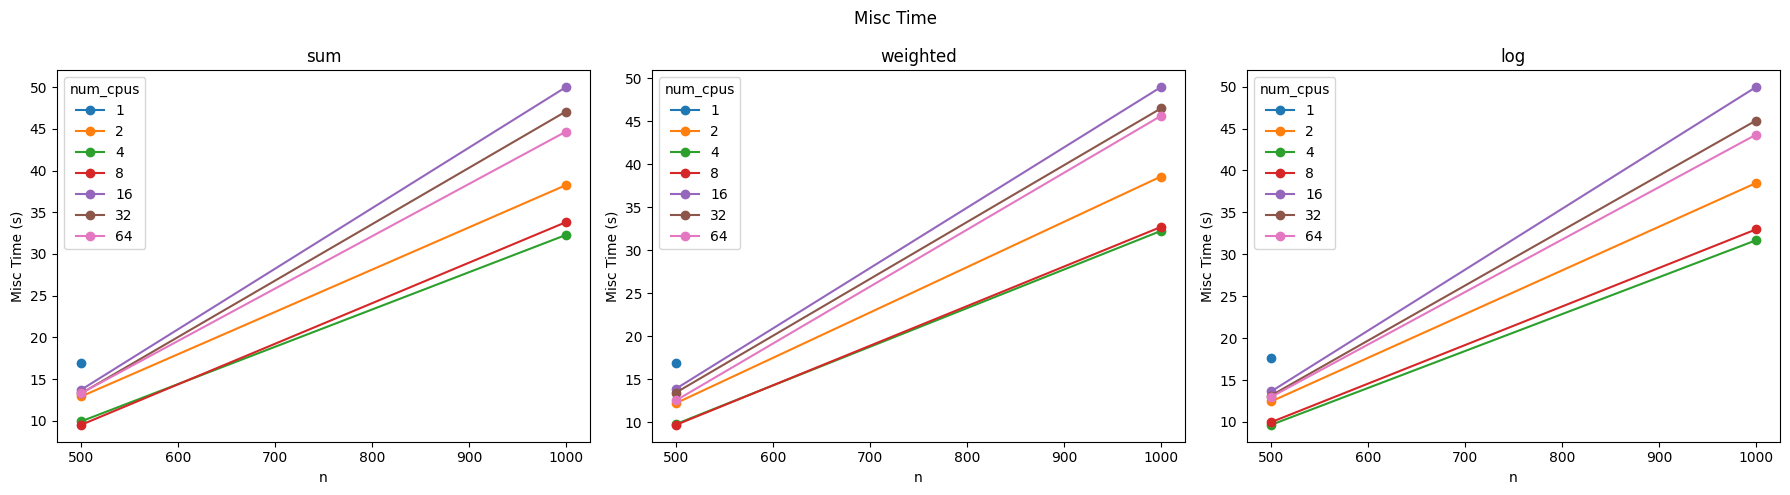

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["misc_time"].plot(ax=ax, marker="o")
    ax.legend(df_t["misc_time"].columns, title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Misc Time (s)")
    ax.set_title(test_type)
fig.suptitle("Misc Time")
fig.tight_layout()
plt.show()

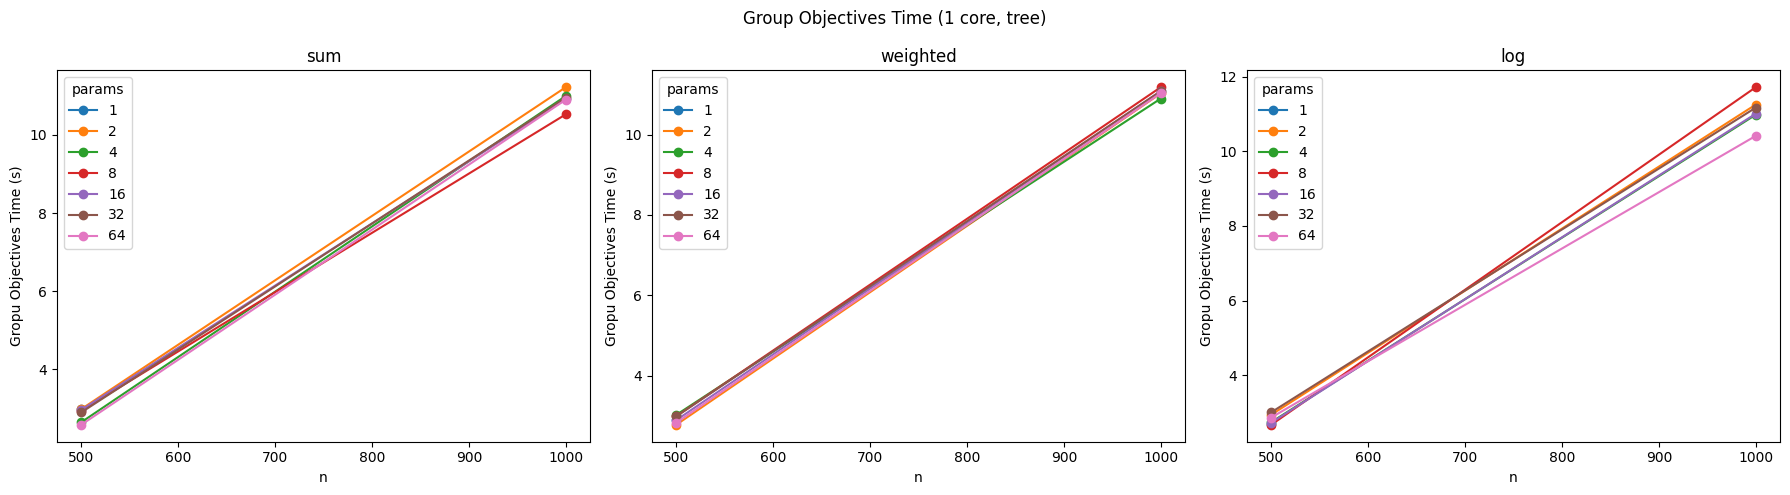

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack(["num_cpus"])
    df_t["_get_grouped_objectives"].plot(ax=ax, marker="o")
    ax.legend(df_t["_get_grouped_objectives"].columns, title="params")
    ax.set_xlabel("n")
    ax.set_ylabel("Gropu Objectives Time (s)")
    ax.set_title(test_type)
fig.suptitle("Group Objectives Time (1 core, tree)")
fig.tight_layout()
plt.show()

In [23]:
dfs = []
for i in [1]:
    dfs.append(pd.read_csv(f"data/{i}core_new.csv"))
df_cvxpy = pd.concat(dfs).set_index(["test_type", "n", "num_cpus"])
df_cvxpy.head()

,,,num_iterations,dede_solve_time,dede_iterations,solve,result
test_type,n,num_cpus,,,,,
sum,500,1,0,NaN,NaN,23.674833,124750.000000
weighted,500,1,0,NaN,NaN,18.218707,2826.713177
log,500,1,0,NaN,NaN,31.948321,2611.261719
sum,1000,1,0,NaN,NaN,149.253446,499500.000000
weighted,1000,1,0,NaN,NaN,132.075961,5698.881113


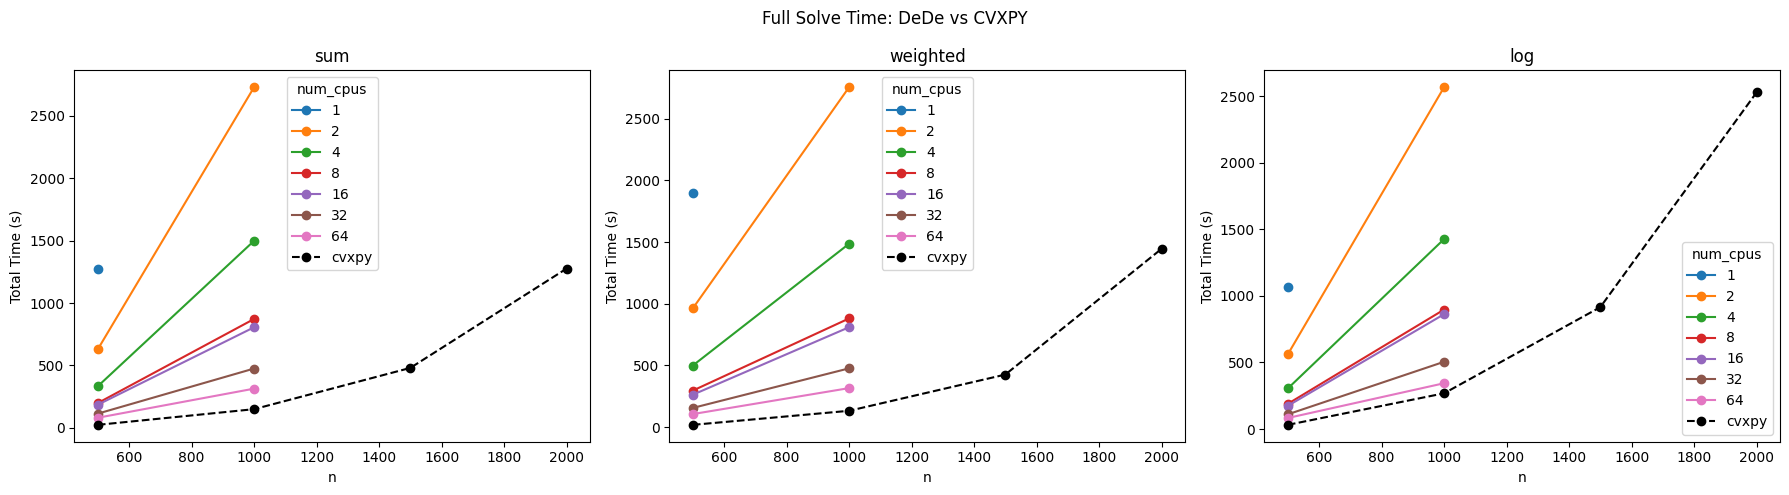

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=SHAREY)
for ax, test_type in zip(axes, TEST_TYPES):
    df_t = df.loc[test_type].unstack("num_cpus")
    df_t["total_time"].plot(ax=ax, marker="o")

    cvxpy_t = df_cvxpy.loc[(test_type, slice(None), 1), "solve"]
    cvxpy_t.index = cvxpy_t.index.get_level_values("n")
    ax.plot(cvxpy_t.index, cvxpy_t.values, marker="o", linestyle="--", color="black", label="cvxpy")

    ax.legend(title="num_cpus")
    ax.set_xlabel("n")
    ax.set_ylabel("Total Time (s)")
    ax.set_title(test_type)
fig.suptitle("Full Solve Time: DeDe vs CVXPY")
fig.tight_layout()
plt.show()

In [26]:
merged = df_cvxpy.merge(df, how="left", on=["test_type", "n", "num_cpus"], suffixes=("_cvxpy", "_dede"))

In [32]:
diffs = merged[["result_cvxpy", "result_dede"]].astype(np.float64).dropna()
diffs["error"] = np.abs(diffs["result_cvxpy"] - diffs["result_dede"]) / np.abs(diffs["result_cvxpy"])

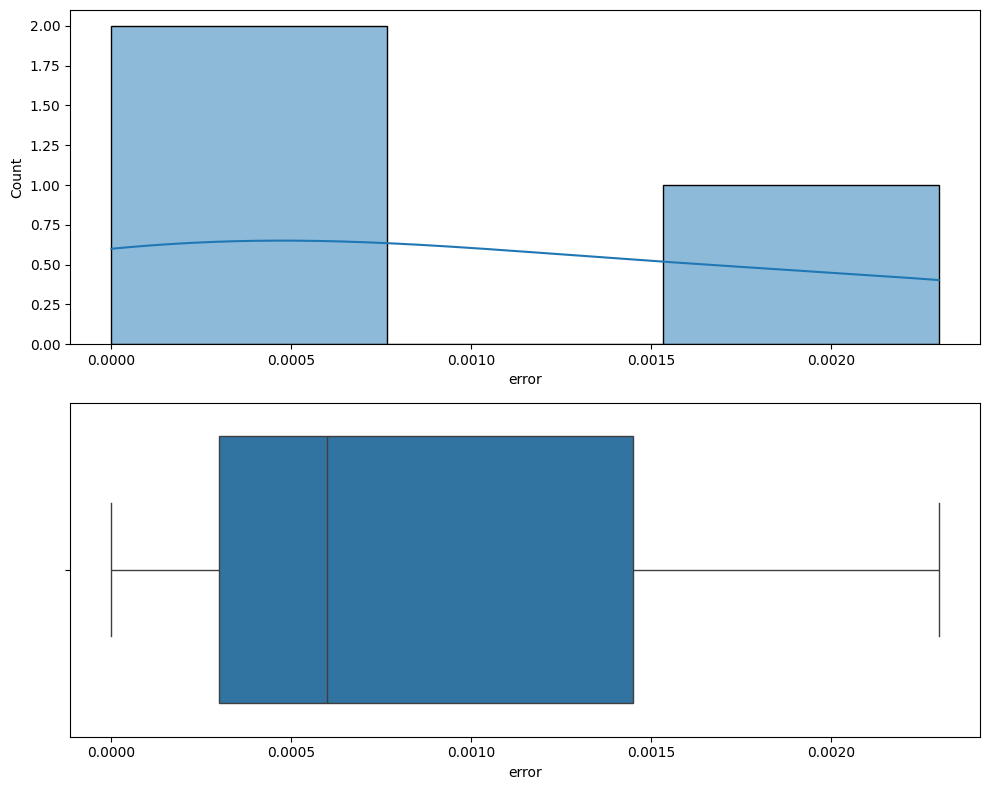

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sns.histplot(diffs["error"], kde=True, ax=axes[0])
sns.boxplot(x=diffs["error"], ax=axes[1])
plt.tight_layout()
plt.show()